In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df1 = pd.read_csv('../data/interim/calfire_topography_vegetation_weather_joined.csv')
df2 = pd.read_csv('../data/interim/fire_drought_interim.csv')

In [3]:
df1.shape,df2.shape

((2576, 117), (3499, 23))

In [4]:
list(df1.columns)

['Unnamed: 0',
 'incident_name',
 'incident_is_final',
 'incident_date_last_update',
 'incident_date_created',
 'incident_administrative_unit',
 'incident_administrative_unit_url',
 'incident_county',
 'incident_location',
 'incident_acres_burned',
 'incident_containment',
 'incident_control',
 'incident_cooperating_agencies',
 'fire_LON',
 'fire_LAT',
 'incident_type',
 'incident_id',
 'incident_url',
 'incident_date_extinguished',
 'incident_dateonly_extinguished',
 'incident_dateonly_created',
 'is_active',
 'calfire_incident',
 'notification_desired',
 'created',
 'log_acres',
 'aspect',
 'elevation',
 'first',
 'hillshade',
 'slope',
 'fire_date',
 'fire_id',
 'matched_veg_LAT',
 'matched_veg_LON',
 'location_distance_degrees',
 'STID',
 'DATE',
 'FUEL_TYPE',
 'FUEL_VARIATION',
 'PERCENT',
 'NAME',
 'GACC',
 'GROUP',
 'veg_LAT',
 'veg_LON',
 'ELE',
 'veg_date',
 'date_gap_days',
 'lon',
 'lat',
 'fire_start_date',
 'original_index',
 'pr_8w',
 'rmax_8w',
 'rmin_8w',
 'sph_8w',
 's

In [5]:
list(df2.columns)

['incident_name',
 'incident_id',
 'DSCI_current',
 'DSCI_4wk_avg',
 'DSCI_8wk_avg',
 'DSCI_12wk_avg',
 'DSCI_16wk_avg',
 'DSCI_25wk_avg',
 'DSCI_36wk_avg',
 'DSCI_42wk_avg',
 'DSCI_52wk_avg',
 'eddi90d_current',
 'spei180d_current',
 'pdsi_current',
 'eddi90d_1wk_avg',
 'spei180d_1wk_avg',
 'pdsi_1wk_avg',
 'eddi90d_2wk_avg',
 'spei180d_2wk_avg',
 'pdsi_2wk_avg',
 'eddi90d_4wk_avg',
 'spei180d_4wk_avg',
 'pdsi_4wk_avg']

In [6]:
df1.groupby('incident_id').size().reset_index(name='count').query('count > 1')

,incident_id,count


In [7]:
df2.groupby('incident_id').size().reset_index(name='count').query('count > 1')

,incident_id,count


In [8]:
df2 = df2.drop(columns='incident_name')

In [9]:
df1 = df1.drop(columns='Unnamed: 0')

In [10]:
df = pd.merge(df1,df2,on='incident_id', how='inner')

In [11]:
df.shape

(2565, 137)

In [12]:
list(df.columns)

['incident_name',
 'incident_is_final',
 'incident_date_last_update',
 'incident_date_created',
 'incident_administrative_unit',
 'incident_administrative_unit_url',
 'incident_county',
 'incident_location',
 'incident_acres_burned',
 'incident_containment',
 'incident_control',
 'incident_cooperating_agencies',
 'fire_LON',
 'fire_LAT',
 'incident_type',
 'incident_id',
 'incident_url',
 'incident_date_extinguished',
 'incident_dateonly_extinguished',
 'incident_dateonly_created',
 'is_active',
 'calfire_incident',
 'notification_desired',
 'created',
 'log_acres',
 'aspect',
 'elevation',
 'first',
 'hillshade',
 'slope',
 'fire_date',
 'fire_id',
 'matched_veg_LAT',
 'matched_veg_LON',
 'location_distance_degrees',
 'STID',
 'DATE',
 'FUEL_TYPE',
 'FUEL_VARIATION',
 'PERCENT',
 'NAME',
 'GACC',
 'GROUP',
 'veg_LAT',
 'veg_LON',
 'ELE',
 'veg_date',
 'date_gap_days',
 'lon',
 'lat',
 'fire_start_date',
 'original_index',
 'pr_8w',
 'rmax_8w',
 'rmin_8w',
 'sph_8w',
 'srad_8w',
 'th_8

In [13]:
df.head(2)

,incident_name,incident_is_final,incident_date_last_update,incident_date_created,incident_administrative_unit,incident_administrative_unit_url,incident_county,incident_location,incident_acres_burned,incident_containment,...,pdsi_current,eddi90d_1wk_avg,spei180d_1wk_avg,pdsi_1wk_avg,eddi90d_2wk_avg,spei180d_2wk_avg,pdsi_2wk_avg,eddi90d_4wk_avg,spei180d_4wk_avg,pdsi_4wk_avg
0,Bridge Fire,Y,2018-01-09T13:46:00Z,2017-10-31T11:22:00Z,Shasta-Trinity National Forest,NaN,Shasta,"I-5 and Turntable Bay, 7 miles NE of Shasta Lake",37.0,100.0,...,-2.53,0.80,-2.09,-2.530,0.53,-2.09,-2.426667,0.552000,-1.506,-2.316000
1,Lake Fire,Y,2013-05-18T19:00:00Z,2013-05-17T13:23:00Z,CAL FIRE/Los Angeles County,NaN,Los Angeles,I-5 Southbound at Lake Hughes Road,712.0,100.0,...,-4.27,1.57,-1.45,-4.255,1.61,-1.45,-4.236667,1.648333,-1.450,-4.128333


In [14]:
df["erc_vpd"] = df["erc_2w"] * df["vpd_2w"]

df["elev_slope"] = df["elevation"] * df["slope"]

df["fm1000_erc"] = df["fm1000_2w"] * df["erc_2w"]

In [15]:
corr_cols = [

    # Topography
    'aspect',
    'elevation',
    'hillshade',
    'slope',

    # Spatial
    'fire_LAT',
    'fire_LON',
    'location_distance_degrees',

    # Fuel / Vegetation
    'PERCENT',
    'ELE',

    # Weather (8 weeks)
    # 'pr_8w',
    # 'rmax_8w',
    # 'rmin_8w',
    # 'sph_8w',
    # 'srad_8w',
    # 'th_8w',
    # 'tmmn_8w',
    # 'tmmx_8w',
    # 'vs_8w',
    # 'bi_8w',
    # 'fm100_8w',
    # 'fm1000_8w',
    # 'erc_8w',
    # 'etr_8w',
    # 'pet_8w',
    # 'vpd_8w',

    # Weather (6 weeks)
    # 'pr_6w',
    # 'rmax_6w',
    # 'rmin_6w',
    # 'sph_6w',
    # 'srad_6w',
    # 'th_6w',
    # 'tmmn_6w',
    # 'tmmx_6w',
    # 'vs_6w',
    # 'bi_6w',
    # 'fm100_6w',
    # 'fm1000_6w',
    # 'erc_6w',
    # 'etr_6w',
    # 'pet_6w',
    # 'vpd_6w',

    # Weather (4 weeks)
    # 'pr_4w',
    # 'rmax_4w',
    # 'rmin_4w',
    # 'sph_4w',
    # 'srad_4w',
    # 'th_4w',
    # 'tmmn_4w',
    # 'tmmx_4w',
    # 'vs_4w',
    # 'bi_4w',
    # 'fm100_4w',
    # 'fm1000_4w',
    # 'erc_4w',
    # 'etr_4w',
    # 'pet_4w',
    # 'vpd_4w',

    # Weather (2 weeks)
    'pr_2w',
    'rmax_2w',
    'rmin_2w',
    'sph_2w',
    'srad_2w',
    'th_2w',
    'tmmn_2w',
    'tmmx_2w',
    'vs_2w',
    'bi_2w',
    'fm100_2w',
    'fm1000_2w',
    'erc_2w',
    'etr_2w',
    'pet_2w',
    'vpd_2w',

    # Drought
    'DSCI_current',
    # 'DSCI_4wk_avg',
    # 'DSCI_8wk_avg',
    # 'DSCI_12wk_avg',
    # 'DSCI_16wk_avg',
    # 'DSCI_25wk_avg',
    # 'DSCI_36wk_avg',
    # 'DSCI_42wk_avg',
    # 'DSCI_52wk_avg',

    # EDDI
    'eddi90d_current',
    # 'eddi90d_1wk_avg',
    # 'eddi90d_2wk_avg',
    # 'eddi90d_4wk_avg',

    # SPEI
    'spei180d_current',
    # 'spei180d_1wk_avg',
    # 'spei180d_2wk_avg',
    # 'spei180d_4wk_avg',

    # PDSI
    'pdsi_current',
    # 'pdsi_1wk_avg',
    # 'pdsi_2wk_avg',
    # 'pdsi_4wk_avg'
]

In [16]:
corr_with_target = (
    df[corr_cols + ['log_acres']]
    .corr()['log_acres']
    .abs()
    .sort_values(ascending=False)
)

In [17]:
strong_predictors = corr_with_target[
    corr_with_target > 0.05
]

print(strong_predictors)

log_acres                    1.000000
elevation                    0.233390
slope                        0.193227
fm1000_2w                    0.179795
rmax_2w                      0.176907
erc_2w                       0.174794
fm100_2w                     0.167627
rmin_2w                      0.153861
DSCI_current                 0.140956
ELE                          0.129795
bi_2w                        0.123552
vpd_2w                       0.092639
eddi90d_current              0.084733
sph_2w                       0.081967
pdsi_current                 0.072674
th_2w                        0.067837
vs_2w                        0.061745
location_distance_degrees    0.060932
spei180d_current             0.056768
pr_2w                        0.054704
etr_2w                       0.052855
Name: log_acres, dtype: float64


In [1]:
0.233390*0.233390

0.054470892099999994

In [18]:
def run_regression_models(df, feature_cols, target_col='log_acres', test_size=0.2, random_state=42):
    data = df[feature_cols + [target_col]].copy()
    data = data.dropna(subset=[target_col])

    X = data[feature_cols]
    y = data[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state
    )

    models = {
        "Linear Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),

        "Elastic Net": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", ElasticNetCV(cv=5, random_state=random_state, max_iter=10000))
        ]),

        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                    n_estimators=500,
                    max_depth=6,
                    min_samples_leaf=10,
                    min_samples_split=20,
                    max_features=0.6,
                    random_state=random_state,
                    n_jobs=-1
            ))
        ]),

        "Extra Trees": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesRegressor(
                n_estimators=500,
                max_depth=5,
                min_samples_leaf=10,
                min_samples_split=20,
                max_features=0.6,
                random_state=random_state,
                n_jobs=-1
            ))
        ]),

        "HistGradientBoosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingRegressor(
                random_state=random_state,
                max_iter=500
            ))
        ])
    }

    # Add XGBoost only if installed
    try:
        from xgboost import XGBRegressor

        models["XGBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBRegressor(
                n_estimators=500,
                learning_rate=0.05,
                max_depth=3,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=random_state,
                n_jobs=-1
            ))
        ])
    except ImportError:
        print("XGBoost is not installed. Skipping XGBoost.")

    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        results.append({
            "Model": name,

            "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
            "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),

            "Train MAE": mean_absolute_error(y_train, y_train_pred),
            "Test MAE": mean_absolute_error(y_test, y_test_pred),

            "Train R2": r2_score(y_train, y_train_pred),
            "Test R2": r2_score(y_test, y_test_pred),

            "Overfit Gap": r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)
        })

    results_df = pd.DataFrame(results).sort_values("Test R2", ascending=False)

    return results_df

<Axes: >

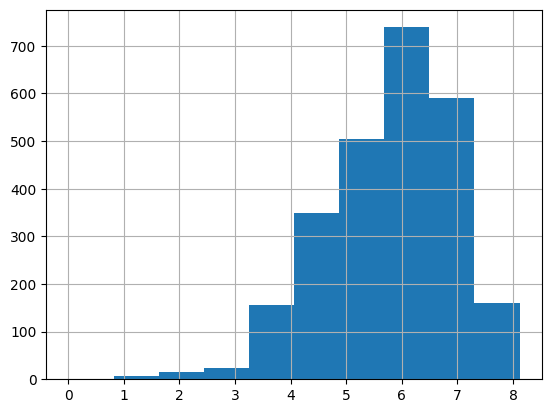

In [20]:
df['log_elevation'].hist()

In [19]:
df['log_elevation'] = np.log1p(df['elevation'])
df['elevation_sq'] = df['elevation']**2
df['elev_slope'] = df['elevation'] * df['slope']
df['elev_hillshade'] = df['elevation'] * df['hillshade']
df['sqrt_elevation'] = np.sqrt(df['elevation'])
df['elev_decile'] = pd.qcut(
    df['elevation'],
    q=10,
    labels=False
)
elev_dummies = pd.get_dummies(
    df['elev_decile'],
    prefix='elev',
    dtype=int
)

df = pd.concat([df, elev_dummies], axis=1)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [21]:
df['log_slope'] = np.log1p(df['slope'])
df['slope_sq'] = df['slope']**2
df['slope_x_erc'] = df['slope'] * df['erc_2w']
df['slope_x_fm1000'] = df['slope'] * df['fm1000_2w']
df['slope_x_elevation'] = df['slope'] * df['elevation']

In [22]:
df['elevation_x_erc'] = df['elevation'] * df['erc_2w']
# df['erc_x_fm1000'] = df['erc_2w'] * df['fm1000_2w']
df['erc_x_vpd'] = df['erc_2w'] * df['vpd_2w']
df['elevation_x_dsci'] = df['elevation'] * df['DSCI_current']

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['elevation_std'] = scaler.fit_transform(df[['elevation']])
df['erc_2w_std'] = scaler.fit_transform(df[['erc_2w']])
df['dsci_current_std'] = scaler.fit_transform(df[['DSCI_current']])
df['slope_std'] = scaler.fit_transform(df[['slope']])
df['fm1000_2w_std'] = scaler.fit_transform(df[['fm1000_2w']])
df['rmax_2w_std'] = scaler.fit_transform(df[['rmax_2w']])
df['fm100_2w_std'] = scaler.fit_transform(df[['fm100_2w']])
df['vpd_2w_std'] = scaler.fit_transform(df[['vpd_2w']])






In [24]:
df['elevation_x_dsci_std'] = df['elevation'] * df['dsci_current_std']

In [179]:
df.drop(columns=fuel_cols,inplace=True)

In [25]:
fuel_type_dummies = pd.get_dummies(
    df['FUEL_TYPE'],
    prefix='fuel_type',
    dtype=int
)

df = pd.concat([df, fuel_type_dummies], axis=1)

df.rename(columns={'fuel_type_Douglas-Fir': 'fuel_type_Douglas_Fir'}, inplace=True)

In [26]:
fuel_cols = [
    'fuel_type_Bitterbrush',
    'fuel_type_Brittlebrush',
    'fuel_type_Buckwheat',
    'fuel_type_Ceanothus',
    'fuel_type_Cedar',
    'fuel_type_Chamise',
    'fuel_type_Chinquapin',
    'fuel_type_Coyotebrush',
    'fuel_type_Douglas_Fir',
    'fuel_type_Fir',
    'fuel_type_Huckleberry',
    'fuel_type_Mahogany',
    'fuel_type_Manzanita',
    'fuel_type_Oak',
    'fuel_type_Pine',
    'fuel_type_Sage',
    'fuel_type_Sagebrush',
    'fuel_type_Tanoak'
]
fuel_type_dict = dict()

for col in fuel_cols:
    fuel_type_dict[col]=df.loc[df[col] == 1, 'log_acres'].mean()
    # print(
    #     col,
    #     df.loc[df[col] == 1, 'log_acres'].mean()
    # )

In [27]:
sorted(fuel_type_dict.items(), key=lambda item: item[1],reverse=True)

[('fuel_type_Tanoak', 2.8311121999926305),
 ('fuel_type_Pine', 2.7689659016180923),
 ('fuel_type_Bitterbrush', 2.4451639954360065),
 ('fuel_type_Sage', 2.3860154357173866),
 ('fuel_type_Mahogany', 2.2979589024910068),
 ('fuel_type_Sagebrush', 2.226767338232198),
 ('fuel_type_Fir', 2.176282388341106),
 ('fuel_type_Douglas_Fir', 2.1662945418273867),
 ('fuel_type_Ceanothus', 2.053471784539245),
 ('fuel_type_Manzanita', 2.0020586898781003),
 ('fuel_type_Chamise', 1.9591898875566802),
 ('fuel_type_Buckwheat', 1.864188827705081),
 ('fuel_type_Coyotebrush', 1.850533902870241),
 ('fuel_type_Oak', 1.7920339589815022),
 ('fuel_type_Brittlebrush', 1.7227418693896022),
 ('fuel_type_Cedar', 1.6295803202276309),
 ('fuel_type_Huckleberry', 1.4559591688792934),
 ('fuel_type_Chinquapin', 1.1760912590556811)]

In [28]:
import statsmodels.formula.api as smf

fuel_vars = " + ".join(['fuel_type_Bitterbrush', 'fuel_type_Brittlebrush',
       'fuel_type_Buckwheat', 'fuel_type_Ceanothus', 'fuel_type_Cedar',
       'fuel_type_Chamise', 'fuel_type_Chinquapin', 'fuel_type_Coyotebrush',
       'fuel_type_Douglas_Fir', 'fuel_type_Fir', 'fuel_type_Huckleberry',
       'fuel_type_Mahogany', 'fuel_type_Manzanita', 'fuel_type_Oak',
       'fuel_type_Pine', 'fuel_type_Sage', 'fuel_type_Sagebrush'
      ])
# 'fuel_type_Tanoak'
model = smf.ols(
    f"log_acres ~ {fuel_vars}",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_acres   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     2.946
Date:                Wed, 24 Jun 2026   Prob (F-statistic):           4.64e-05
Time:                        15:57:01   Log-Likelihood:                -3302.3
No. Observations:                2565   AIC:                             6641.
Df Residuals:                    2547   BIC:                             6746.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2

In [213]:
# df_incident_county = df.groupby(['incident_county']).size().reset_index(name='incident_count_by_county')

In [214]:
# df = pd.merge(df,df_incident_county,on='incident_county',how='inner')

In [29]:
df_years_since_last_fire = df.copy()

df_years_since_last_fire['incident_dateonly_created'] = pd.to_datetime(
    df_years_since_last_fire['incident_dateonly_created']
)

df_years_since_last_fire = df_years_since_last_fire.sort_values(
    ['incident_county', 'incident_dateonly_created']
)

df_years_since_last_fire['previous_fire_date'] = (
    df_years_since_last_fire
    .groupby('incident_county')['incident_dateonly_created']
    .shift(1)
)

df_years_since_last_fire['years_since_last_fire'] = (
    (
        df_years_since_last_fire['incident_dateonly_created']
        - df_years_since_last_fire['previous_fire_date']
    ).dt.days / 365.25
)

In [36]:
df = df.merge(
    df_years_since_last_fire[
        ['incident_id', 'previous_fire_date', 'years_since_last_fire']
    ],
    on='incident_id',
    how='left'
)

In [37]:
df[['log_acres', 'incident_count_by_county', 'years_since_last_fire']].corr()

KeyError: "['incident_count_by_county', 'years_since_last_fire'] not in index"

In [32]:
df_lat_long = df[['fire_LAT','fire_LON']].drop_duplicates()

In [33]:
df_lat_long

,fire_LAT,fire_LON
0,40.774000,-122.309000
1,34.491490,-118.610044
2,38.049930,-120.903250
3,32.564465,-116.900368
4,33.121110,-116.525790
...,...,...
2559,34.780200,-118.350100
2560,35.442023,-118.904257
2561,37.125200,-121.088668
2563,36.209064,-120.391217


In [240]:
df_lat_long.to_csv('df_lat_long.csv')

In [34]:
df_distance_metrics = pd.read_csv('../data/interim/df_with_spatial_metrics.csv')

In [35]:
set(df_distance_metrics.distance_to_city_km)

{0.0,
 0.0060068325825008,
 0.2716066125399671,
 0.3113387498286216,
 0.4612857435801657,
 0.4630560072317591}

In [38]:
df_distance_metrics.columns

Index(['system:index', 'distance_to_city_km', 'distance_to_coast_km',
       'distance_to_road_km', 'fire_LAT', 'fire_LON', 'population_density',
       '.geo'],
      dtype='object')

In [39]:
geo_cols=['fire_LAT',
    'fire_LON',
    'distance_to_city_km',
    'population_density']
df = df.merge(
    df_distance_metrics[geo_cols],
    on=['fire_LAT', 'fire_LON'],
    how='left'
)

In [40]:
df['_orig_order'] = range(len(df))

df['incident_dateonly_created'] = pd.to_datetime(df['incident_dateonly_created'])

df = df.sort_values(['incident_county', 'incident_dateonly_created'])

df['previous_incident_count_by_county'] = (
    df.groupby('incident_county')
      .cumcount()
)

df = df.sort_values('_orig_order').drop(columns='_orig_order')

In [41]:
df_spatial = pd.read_csv('../data/interim/df_with_all_spatial_distances.csv')
df_spatial.columns

Index(['Unnamed: 0', 'fire_LAT', 'fire_LON', 'distance_to_road_km',
       'distance_to_city_km', 'distance_to_coast_km'],
      dtype='object')

In [54]:
dist_spatial_cols=['fire_LAT',
    'fire_LON',
    'distance_to_road_km',
    'distance_to_city_km',
    'distance_to_coast_km']
df = df.merge(
    df_spatial[dist_spatial_cols],
    on=['fire_LAT', 'fire_LON'],
    how='left'
)

In [53]:
# list(df.columns)

In [51]:
# df.drop(columns=['distance_to_road_km_x','distance_to_city_km_y','distance_to_road_km_y','distance_to_city_km','distance_to_coast_km_y'],inplace=True)

In [43]:
df['log_population_density'] = np.log1p(
    df['population_density']
)

In [55]:
df['city_x_pop'] = (
    df['distance_to_city_km']
    * np.log1p(df['population_density'])
)

df['coast_x_erc'] = (
    df['distance_to_coast_km']
    * df['erc_2w_std']
)

In [56]:
# list(df.columns)
df['vs_2w_std'] = scaler.fit_transform(df[['vs_2w']])

In [57]:
df['temp_x_wind'] = df['tmmx_2w'] * df['vs_2w']
df['temp_x_wind_std'] = scaler.fit_transform(df[['temp_x_wind']])

In [58]:
df['wind_x_fuel'] = df['vs_2w'] * df['fm1000_2w']
df['wind_x_fuel_std'] = scaler.fit_transform(df[['wind_x_fuel']])

In [59]:
df['temp_x_fuel'] = df['tmmx_2w'] * df['fm1000_2w']

In [60]:
df['wind_x_lowhumidity'] = (
    df['vs_2w'] * (100 - df['rmin_2w'])
)

In [61]:
df['fuel_x_lowhumidity'] = (
    df['fm1000_2w'] * (100 - df['rmin_2w'])
)

In [62]:
df['temp_wind_fuel'] = (
    df['tmmx_2w']
    * df['vs_2w']
    * df['fm1000_2w']
)

In [63]:
df['temp_wind_fuel_std'] = scaler.fit_transform(df[['temp_wind_fuel']])

In [64]:
df['tmmx_2w_sq'] = df['tmmx_2w']**2

In [65]:
df['vs_2w_sq'] = df['vs_2w']**2

In [66]:
df['month'] = pd.to_datetime(
    df['incident_dateonly_created']
).dt.month

In [67]:
month_dummies = pd.get_dummies(
    df['month'],
    prefix='month',
    dtype=int
)

df = pd.concat([df, month_dummies], axis=1)

In [68]:
df['month_sin'] = np.sin(
    2 * np.pi * df['month'] / 12
)

df['month_cos'] = np.cos(
    2 * np.pi * df['month'] / 12
)

In [69]:
df_powerlines = pd.read_csv('../data/interim/df_with_powerlines.csv')
df_powerlines.columns
df_powerlines_cols=['fire_LAT',
    'fire_LON',
    'distance_to_powerline_km']
df = df.merge(
    df_powerlines[df_powerlines_cols],
    on=['fire_LAT', 'fire_LON'],
    how='left'
)

In [70]:
# list(df.columns)

In [71]:
fuel_var_dummies = pd.get_dummies(
    df['FUEL_VARIATION'],
    prefix='fuel_var',
    dtype=int
)

df = pd.concat([df, fuel_var_dummies], axis=1)

In [72]:
fuel_var_dummies.columns

Index(['fuel_var_Alderleaf Mountain', 'fuel_var_Bigberry', 'fuel_var_Black',
       'fuel_var_Buckbrush', 'fuel_var_Bush', 'fuel_var_California',
       'fuel_var_California Live', 'fuel_var_Coastal',
       'fuel_var_Curl-Leaf Mountain', 'fuel_var_Deerbrush', 'fuel_var_Desert',
       'fuel_var_Eastern Mojave', 'fuel_var_Eastwoods', 'fuel_var_Grand',
       'fuel_var_Greenleaf', 'fuel_var_Hoaryleaf', 'fuel_var_Incense',
       'fuel_var_Mountain Big', 'fuel_var_New Growth', 'fuel_var_Old Growth',
       'fuel_var_Ponderosa', 'fuel_var_Silver', 'fuel_var_Snowbrush',
       'fuel_var_Thinleaf', 'fuel_var_Whiteleaf', 'fuel_var_Whitethorn'],
      dtype='object')

In [73]:
county_means = df.groupby('incident_county')['log_acres'].mean()
df['county_historical_mean_log_acres'] = df['incident_county'].map(county_means)

In [74]:


# 1. Tag the original index order to safely restore later
df['_orig_order'] = range(len(df))

# 2. Ensure chronological order within each county context
df['incident_dateonly_created'] = pd.to_datetime(df['incident_dateonly_created'])
df = df.sort_values(['incident_county', 'incident_dateonly_created'])

# 3. Step A: Get the running count of prior incidents (your current approach)
df['previous_incident_count_by_county'] = (
    df.groupby('incident_county')
      .cumcount()
)

# 4. Step B: Get the cumulative sum of fire sizes including the current row
df['_cum_sum_acres'] = (
    df.groupby('incident_county')['log_acres']
      .cumsum()
)

# 5. Step C: Subtract the current fire's acres to isolate STRICTLY PAST historical totals
# (This completely eliminates future target leakage)
df['_past_sum_acres'] = df['_cum_sum_acres'] - df['log_acres']

# 6. Step D: Calculate the mean (Past Total Size / Past Count)
df['county_historical_mean_log_acres'] = df['_past_sum_acres'] / df['previous_incident_count_by_county']

# 7. Step E: Handle the first fire in a county (0 divided by 0 creates NaN)
# We fill it with the global historical mean up to that point to avoid model crashes
global_mean = df['log_acres'].mean()
df['county_historical_mean_log_acres'] = df['county_historical_mean_log_acres'].fillna(global_mean)

# 8. Clean up temporary tracking columns and restore your original row order perfectly
df = df.sort_values('_orig_order').drop(columns=[
    '_orig_order', 
    '_cum_sum_acres', 
    '_past_sum_acres'
])

In [75]:

# 1. Calculate the active duration (days burnt) for each specific fire row
df['incident_dateonly_created'] = pd.to_datetime(df['incident_dateonly_created'])
df['incident_dateonly_extinguished'] = pd.to_datetime(df['incident_dateonly_extinguished'])

# Calculate raw duration in days. If a fire is put out the same day, it becomes 0.
df['days_burnt'] = (df['incident_dateonly_extinguished'] - df['incident_dateonly_created']).dt.days

# Handle any open/unextinguished fires or missing data by filling with a placeholder or median
# (So the cumulative sum doesn't propagate NaNs down the row chain)
median_days_burnt = df['days_burnt'].median()
df['days_burnt'] = df['days_burnt'].fillna(median_days_burnt)

# 2. Tag the original index order to safely restore later
df['_orig_order'] = range(len(df))

# 3. Sort chronologically within each county context
df = df.sort_values(['incident_county', 'incident_dateonly_created'])

# 4. Get the running count of prior incidents (Your base layer)
df['previous_incident_count_by_county'] = (
    df.groupby('incident_county')
      .cumcount()
)

# ==========================================
# FEATURE 1: Historical Mean of Log Acres
# ==========================================
df['_cum_sum_acres'] = df.groupby('incident_county')['log_acres'].cumsum()
df['_past_sum_acres'] = df['_cum_sum_acres'] - df['log_acres']
df['county_historical_mean_log_acres'] = df['_past_sum_acres'] / df['previous_incident_count_by_county']

# ==========================================
# FEATURE 2: Historical Mean of Days Burnt (NEW)
# ==========================================
df['_cum_sum_days'] = df.groupby('incident_county')['days_burnt'].cumsum()
df['_past_sum_days'] = df['_cum_sum_days'] - df['days_burnt']
df['county_historical_mean_days_burnt'] = df['_past_sum_days'] / df['previous_incident_count_by_county']

# ==========================================
# 5. Clean Up and Restore Index Order
# ==========================================
# Fill NaN values for the first fire of a county with global dataset averages
global_mean_acres = df['log_acres'].mean()
global_mean_days = df['days_burnt'].mean()

df['county_historical_mean_log_acres'] = df['county_historical_mean_log_acres'].fillna(global_mean_acres)
df['county_historical_mean_days_burnt'] = df['county_historical_mean_days_burnt'].fillna(global_mean_days)

# Restore original row structure completely
df = df.sort_values('_orig_order').drop(columns=[
    '_orig_order', 
    '_cum_sum_acres', 
    '_past_sum_acres',
    '_cum_sum_days', 
    '_past_sum_days'
])

In [76]:
df['hot_dry_windy_proxy'] = df['tmmx_8w'] * (100 - df['rmin_8w']) * df['vs_8w']

In [77]:
df['erc_stability_ratio'] = df['erc_8w'] / (df['erc_2w_std'] + 0.1)

In [78]:
df['creation_month'] = pd.to_datetime(df['incident_dateonly_created']).dt.month
df['month_sin'] = np.sin(2 * np.pi * df['creation_month'] / 12.0)
df['month_cos'] = np.cos(2 * np.pi * df['creation_month'] / 12.0)

In [79]:
df['slope_acceleration_potential'] = df['slope'] * df['vs_8w']

In [80]:
# Convert aspect degrees to a southwest-facing alignment metric
df['southwest_aspect_exposure'] = np.cos((df['aspect'] - 210) * np.pi / 180.0)

In [81]:
# Create a rolling historical target encoding for vegetation types
df['_orig_order'] = range(len(df))
df = df.sort_values(['FUEL_TYPE', 'incident_dateonly_created'])

# 1. Running count of fires inside this fuel type
df['_veg_count'] = df.groupby('FUEL_TYPE').cumcount()

# 2. Running sum of fire sizes in this fuel type
df['_veg_cum_sum'] = df.groupby('FUEL_TYPE')['log_acres'].cumsum()

# 3. Exclude current row to prevent target leakage
df['_veg_past_sum'] = df['_veg_cum_sum'] - df['log_acres']
df['fuel_type_historical_mean_log_acres'] = df['_veg_past_sum'] / df['_veg_count']

# 4. Fill initial instances with the global average
df['fuel_type_historical_mean_log_acres'] = df['fuel_type_historical_mean_log_acres'].fillna(df['log_acres'].mean())

# Restore original order
df = df.sort_values('_orig_order').drop(columns=['_orig_order', '_veg_count', '_veg_cum_sum', '_veg_past_sum'])

In [82]:
# High values mean both immediate air dryness AND long-term drought are peaking simultaneously
df['atmospheric_deep_drought_stress'] = df['vpd_2w_std'] * df['eddi90d_1wk_avg']

In [83]:
# Determine extreme thresholds from the training data distribution (e.g., 90th percentiles)
vpd_90 = df['vpd_2w_std'].quantile(0.90)
eddi_90 = df['eddi90d_1wk_avg'].quantile(0.90)

# Create a clear step-function trigger: 1 if BOTH are extreme, 0 otherwise
df['red_flag_critical_threshold'] = ((df['vpd_2w_std'] >= vpd_90) & 
                                     (df['eddi90d_1wk_avg'] >= eddi_90)).astype(int)

In [84]:
# Coarse spatial clustering to capture regional macro-climates
df['spatial_zone_north_south'] = (df['fire_LAT'] // 1.5).astype(int)
df['spatial_zone_east_west']   = (df['fire_LON'] // 1.5).astype(int)

# Target encode these structural spatial grids to capture regional baselines
df['_orig_order'] = range(len(df))
df = df.sort_values(['spatial_zone_north_south', 'spatial_zone_east_west', 'incident_dateonly_created'])

df['_zone_count'] = df.groupby(['spatial_zone_north_south', 'spatial_zone_east_west']).cumcount()
df['_zone_cumsum'] = df.groupby(['spatial_zone_north_south', 'spatial_zone_east_west'])['log_acres'].cumsum()
df['zone_historical_mean_log_acres'] = (df['_zone_cumsum'] - df['log_acres']) / df['_zone_count']
df['zone_historical_mean_log_acres'] = df['zone_historical_mean_log_acres'].fillna(df['log_acres'].mean())

df = df.sort_values('_orig_order').drop(columns=['_orig_order', '_zone_count', '_zone_cumsum'])

In [85]:
# As distance increases AND slope increases, accessibility drops exponentially
df['suppression_difficulty_index'] = df['distance_to_road_km'] * np.exp(df['slope'] / 10.0)

In [86]:
df['offshore_wind_delivery'] = ((df['th_8w'] >= 22.5) & (df['th_8w'] <= 67.5)).astype(int) * df['vs_8w']

In [87]:
# Calculate historical mean log_acres within administrative command structures
df['_admin_count'] = df.groupby('incident_administrative_unit').cumcount()
df['_admin_cumsum'] = df.groupby('incident_administrative_unit')['log_acres'].cumsum()
df['admin_unit_historical_mean_log_acres'] = (df['_admin_cumsum'] - df['log_acres']) / df['_admin_count']
df['admin_unit_historical_mean_log_acres'] = df['admin_unit_historical_mean_log_acres'].fillna(df['log_acres'].mean())

In [88]:
df['vpd_drying_trend'] = df['vpd_2w'] - df['vpd_4w']

In [89]:
df['erc_acceleration'] = df['erc_2w'] - df['erc_4w']

In [90]:
df['dsci_annual_severity_ratio'] = df['DSCI_current'] / (df['DSCI_52wk_avg'] + 1.0)

In [91]:
df.columns

Index(['incident_name', 'incident_is_final', 'incident_date_last_update',
       'incident_date_created', 'incident_administrative_unit',
       'incident_administrative_unit_url', 'incident_county',
       'incident_location', 'incident_acres_burned', 'incident_containment',
       ...
       'spatial_zone_east_west', 'zone_historical_mean_log_acres',
       'suppression_difficulty_index', 'offshore_wind_delivery',
       '_admin_count', '_admin_cumsum', 'admin_unit_historical_mean_log_acres',
       'vpd_drying_trend', 'erc_acceleration', 'dsci_annual_severity_ratio'],
      dtype='object', length=280)

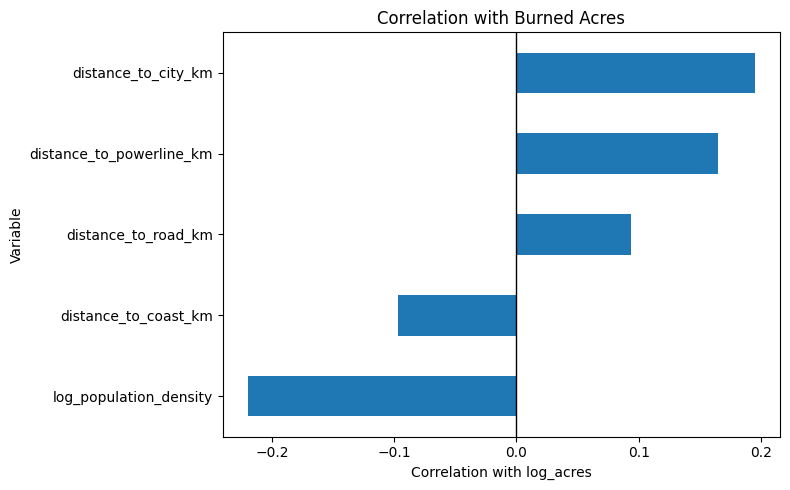

In [92]:
df[['log_acres', 'log_population_density',
    'distance_to_city_km',
    'distance_to_coast_km',
    'distance_to_road_km',
    'distance_to_powerline_km',]].corr()['log_acres']
corr_vals = (
    df[
        [
            'log_acres',
            'log_population_density',
            'distance_to_city_km',
            'distance_to_coast_km',
            'distance_to_road_km',
            'distance_to_powerline_km'
        ]
    ]
    .corr()['log_acres']
    .drop('log_acres')
    .sort_values()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
corr_vals.plot(kind='barh')

plt.axvline(0, color='black', linewidth=1)

plt.xlabel('Correlation with log_acres')
plt.ylabel('Variable')
plt.title('Correlation with Burned Acres')
plt.tight_layout()
plt.show()

In [93]:
df.to_csv('df.csv')

In [94]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neural_network import MLPRegressor

# Import regressors
from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor

# Force scikit-learn transformers to output DataFrames to keep LightGBM feature names happy
import sklearn
sklearn.set_config(transform_output="pandas")

def run_regression_models(df, feature_cols, target_col='log_acres', test_size=0.2, random_state=42):
    data = df[feature_cols + [target_col]].copy()
    data = data.dropna(subset=[target_col])

    X = data[feature_cols]
    y = data[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=test_size,
        random_state=random_state
    )

    models = {
        "Linear Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LinearRegression())
        ]),

        "Elastic Net": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", ElasticNetCV(cv=5, random_state=random_state, max_iter=10000))
        ]),

        # --- RANDOM FOREST ANTI-OVERFIT ---
        # 1. Lowered max_depth to stop micro-splitting on exact coordinates.
        # 2. Increased min_samples_leaf so a leaf must capture at least 25 fires to be valid.
        # 3. Restricted max_features to 40% per split to force tree diversity.
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=500,
                max_depth=5,                 # Aggressively limited from 6
                min_samples_leaf=25,         # Increased from 10 to force generalization
                min_samples_split=50,        # Increased from 20
                max_features=0.4,            # Decreased from 0.6 to reduce feature reliance
                random_state=random_state,
                n_jobs=-1
            ))
        ]),

        "Extra Trees": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesRegressor(
                n_estimators=500,
                max_depth=5,
                min_samples_leaf=20,
                min_samples_split=40,
                max_features=0.4,
                random_state=random_state,
                n_jobs=-1
            ))
        ]),

        # --- HIST GRADIENT BOOSTING ANTI-OVERFIT ---
        # 1. Max iterations capped to avoid over-learning target residuals.
        # 2. Implemented strict max_depth and min_samples_leaf ceilings.
        "HistGradientBoosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingRegressor(
                random_state=random_state,
                max_iter=300,                # Reduced from 500 to prevent late-stage memorization
                max_depth=4,                 # Controlled depth
                min_samples_leaf=35,         # Large leaf minimum size requirement
                l2_regularization=10.0       # Added strong L2 penalty on leaf values
            ))
        ]),

           "Neural Network": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPRegressor(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.01,
                learning_rate_init=0.001,
                max_iter=1000,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=25,
                random_state=random_state
            ))
        ]),
    }

 

    # --- LIGHTGBM ANTI-OVERFIT ---
    # 1. Max depth combined with limited num_leaves handles tree structural growth.
    # 2. min_child_samples=35 mirrors scikit-learn's leaf requirements.
    # 3. reg_alpha and reg_lambda introduce powerful L1/L2 mathematical shrinkage.
    try:
        from lightgbm import LGBMRegressor
        
        models["LightGBM"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", LGBMRegressor(
                n_estimators=400,
                learning_rate=0.02,          # Dropped from 0.03 to slow down learning rate
                max_depth=4,                 # Strict layer count ceiling
                num_leaves=15,               # Explicitly kept low to force broad splits
                min_child_samples=35,        # Leaves must encompass at least 35 fire instances
                subsample=0.7,               # Train each tree on a random 70% fraction of rows
                colsample_bytree=0.7,        # Train each tree on a random 70% fraction of features
                reg_alpha=10.0,              # Heavy L1 penalty to ignore weak/noisy variance features
                reg_lambda=15.0,             # Heavy L2 penalty to smooth final leaf leaf predictions
                random_state=random_state,
                alpha= 0.90,
                n_jobs=-1,
                verbose=-1


            ))
        ])
    except ImportError:
        print("LightGBM is not installed. Skipping LightGBM.")

    # --- XGBOOST ANTI-OVERFIT ---
    # 1. Kept max_depth thin at 3 (highly generalizable, macro relationships only).
    # 2. reg_alpha and reg_lambda penalties added directly into gradient math.
    try:
        from xgboost import XGBRegressor

        models["XGBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBRegressor(
                n_estimators=400,
                learning_rate=0.03,          # Dropped from 0.05
                max_depth=3,                 # Kept tight to prevent deep branch memory lookups
                subsample=0.7,               # row fraction masking
                colsample_bytree=0.7,        # feature fraction masking
                reg_alpha=10.0,              # L1 Regularization penalty
                reg_lambda=15.0,             # L2 Regularization penalty
                objective="reg:squarederror",
                random_state=random_state,
                n_jobs=-1
            ))
        ])
    except ImportError:
        print("XGBoost is not installed. Skipping XGBoost.")



    # 4. Evaluation Loop
    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        results.append({
            "Model": name,

            "Train RMSE": np.sqrt(mean_squared_error(y_train, y_train_pred)),
            "Test RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),

            "Train MAE": mean_absolute_error(y_train, y_train_pred),
            "Test MAE": mean_absolute_error(y_test, y_test_pred),

            "Train R2": r2_score(y_train, y_train_pred),
            "Test R2": r2_score(y_test, y_test_pred),

            "Overfit Gap": r2_score(y_train, y_train_pred) - r2_score(y_test, y_test_pred)
        })

    results_df = pd.DataFrame(results).sort_values("Test R2", ascending=False)

    return results_df

In [95]:
df[   [ 'log_population_density',
    'distance_to_city_km',
    'distance_to_coast_km',
    'distance_to_road_km']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 2565 entries, 0 to 2564
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   log_population_density  2565 non-null   float64
 1   distance_to_city_km     2565 non-null   float64
 2   distance_to_coast_km    2565 non-null   float64
 3   distance_to_road_km     2565 non-null   float64
dtypes: float64(4)
memory usage: 100.2 KB


In [96]:
feature_cols = [



    
    # Terrain
    'elevation', 'slope', 'aspect',

    # Fire danger
    'erc_2w_std',    
    'vpd_2w_std',
    'dsci_current_std', 'hot_dry_windy_proxy',
    'eddi90d_1wk_avg',
    'spei180d_1wk_avg',
    'pdsi_1wk_avg',

    # Interaction
    'elevation_x_erc',

    # Fuel
    'fuel_type_historical_mean_log_acres',

    # Fire history
    'previous_incident_count_by_county',

    # Human Geography
    'log_population_density',
    'distance_to_city_km',
    'distance_to_coast_km',
    'distance_to_road_km',
    'distance_to_powerline_km',
    'county_historical_mean_log_acres',
    'county_historical_mean_days_burnt',

    # 'admin_unit_historical_mean_log_acres', 
    # 'vpd_drying_trend',
    # 'erc_acceleration',
    # 'dsci_annual_severity_ratio',
    
    # 'fuel_type_Pine',
    # 'fuel_type_Tanoak',
    # 'fuel_type_Bitterbrush',
    # 'fuel_type_Sagebrush',

    # 'zone_historical_mean_log_acres',
    # 'elevation_std',
    # 'slope_std',
    'offshore_wind_delivery',

    # 'tmmx_2w', # temp max
    # 'vs_2w', # wind
    # 'fm1000_2w', # fuel dryness
    # 'rmin_2w', # humidity



    

]

results_df = run_regression_models(
    df=df,
    feature_cols=feature_cols,
    target_col='log_acres'
)

results_df

,Model,Train RMSE,Test RMSE,Train MAE,Test MAE,Train R2,Test R2,Overfit Gap
7,XGBoost,0.694523,0.714388,0.528113,0.547759,0.396873,0.287150,0.109723
6,LightGBM,0.687604,0.717064,0.522771,0.550793,0.408831,0.281799,0.127032
2,Random Forest,0.755876,0.732756,0.575428,0.565084,0.285609,0.250022,0.035587
4,HistGradientBoosting,0.462941,0.749351,0.352672,0.571148,0.732030,0.215667,0.516363
0,Linear Regression,0.811714,0.773838,0.613946,0.603507,0.176163,0.163570,0.012593
3,Extra Trees,0.807593,0.775752,0.615350,0.600201,0.184507,0.159426,0.025081
1,Elastic Net,0.814535,0.775923,0.617337,0.603272,0.170428,0.159055,0.011373
5,Neural Network,0.755759,0.806154,0.570272,0.609579,0.285829,0.092250,0.193580


In [97]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)
from sklearn.neural_network import MLPClassifier

import sklearn
sklearn.set_config(transform_output="pandas")


def run_classification_models(
    df,
    feature_cols,
    target_col='log_acres',
    test_size=0.2,
    random_state=42
):
    data = df[feature_cols + [target_col]].copy()
    data = data.dropna(subset=[target_col])

    # Create fire size classes from log_acres
    data['fire_size_class'] = pd.qcut(
        data[target_col],
        q=3,
        labels=['Low', 'Medium', 'High']
    )

    X = data[feature_cols]
    y = data['fire_size_class']

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_encoded,
        test_size=test_size,
        random_state=random_state,
        stratify=y_encoded
    )

    models = {
        "Logistic Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=5000,
                random_state=random_state,
                class_weight="balanced"
            ))
        ]),

        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=500,
                max_depth=5,
                min_samples_leaf=25,
                min_samples_split=50,
                max_features=0.4,
                random_state=random_state,
                n_jobs=-1,
                class_weight="balanced"
            ))
        ]),

        "Extra Trees": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", ExtraTreesClassifier(
                n_estimators=500,
                max_depth=5,
                min_samples_leaf=20,
                min_samples_split=40,
                max_features=0.4,
                random_state=random_state,
                n_jobs=-1,
                class_weight="balanced"
            ))
        ]),

        "HistGradientBoosting": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", HistGradientBoostingClassifier(
                random_state=random_state,
                max_iter=300,
                max_depth=4,
                min_samples_leaf=35,
                l2_regularization=10.0
            ))
        ]),

        "Neural Network": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                hidden_layer_sizes=(64, 32),
                activation="relu",
                solver="adam",
                alpha=0.01,
                learning_rate_init=0.001,
                max_iter=1000,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=25,
                random_state=random_state
            ))
        ])
    }

    try:
        from lightgbm import LGBMClassifier

        models["LightGBM"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", LGBMClassifier(
                n_estimators=400,
                learning_rate=0.02,
                max_depth=4,
                num_leaves=15,
                min_child_samples=35,
                subsample=0.7,
                colsample_bytree=0.7,
                reg_alpha=10.0,
                reg_lambda=15.0,
                random_state=random_state,
                n_jobs=-1,
                verbose=-1
            ))
        ])
    except ImportError:
        print("LightGBM is not installed. Skipping LightGBM.")

    try:
        from xgboost import XGBClassifier

        models["XGBoost"] = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(
                n_estimators=400,
                learning_rate=0.03,
                max_depth=3,
                subsample=0.7,
                colsample_bytree=0.7,
                reg_alpha=10.0,
                reg_lambda=15.0,
                eval_metric="mlogloss",
                random_state=random_state,
                n_jobs=-1
            ))
        ])
    except ImportError:
        print("XGBoost is not installed. Skipping XGBoost.")

    results = []
    fitted_models = {}

    for name, model in models.items():
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_acc = accuracy_score(y_train, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        results.append({
            "Model": name,

            "Train Accuracy": train_acc,
            "Test Accuracy": test_acc,

            "Train Precision": precision_score(
                y_train,
                y_train_pred,
                average="weighted",
                zero_division=0
            ),
            "Test Precision": precision_score(
                y_test,
                y_test_pred,
                average="weighted",
                zero_division=0
            ),

            "Train Recall": recall_score(
                y_train,
                y_train_pred,
                average="weighted",
                zero_division=0
            ),
            "Test Recall": recall_score(
                y_test,
                y_test_pred,
                average="weighted",
                zero_division=0
            ),

            "Train F1": f1_score(
                y_train,
                y_train_pred,
                average="weighted",
                zero_division=0
            ),
            "Test F1": f1_score(
                y_test,
                y_test_pred,
                average="weighted",
                zero_division=0
            ),

            "Overfit Gap": train_acc - test_acc
        })

        fitted_models[name] = model

    results_df = (
        pd.DataFrame(results)
        .sort_values("Test F1", ascending=False)
        .reset_index(drop=True)
    )

    return results_df, fitted_models, label_encoder

In [98]:
results_df, fitted_models, label_encoder = run_classification_models(
    df=df,
    feature_cols=feature_cols,
    target_col='log_acres'
)

results_df

,Model,Train Accuracy,Test Accuracy,Train Precision,Test Precision,Train Recall,Test Recall,Train F1,Test F1,Overfit Gap
0,Logistic Regression,0.494152,0.512671,0.490230,0.507362,0.494152,0.512671,0.489385,0.506828,-0.018519
1,Extra Trees,0.544347,0.516569,0.548728,0.512292,0.544347,0.516569,0.531971,0.504621,0.027778
2,Random Forest,0.577973,0.508772,0.577042,0.504804,0.577973,0.508772,0.574066,0.504518,0.069201
3,Neural Network,0.513158,0.489279,0.507721,0.482978,0.513158,0.489279,0.504909,0.482793,0.023879
4,XGBoost,0.604776,0.487329,0.604795,0.481022,0.604776,0.487329,0.601918,0.482247,0.117446
5,LightGBM,0.649123,0.481481,0.649467,0.475776,0.649123,0.481481,0.646580,0.476656,0.167641
6,HistGradientBoosting,0.986842,0.454191,0.986852,0.453872,0.986842,0.454191,0.986833,0.453961,0.532651


In [99]:
label_encoder.classes_

array(['High', 'Low', 'Medium'], dtype=object)

In [100]:
best_model_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_model_name]

data = df[feature_cols + ['log_acres']].dropna(subset=['log_acres']).copy()

data['fire_size_class'] = pd.qcut(
    data['log_acres'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

X = data[feature_cols]
y = label_encoder.transform(data['fire_size_class'])

_, X_test, _, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_pred = best_model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

[[ 95  37  39]
 [ 31 107  34]
 [ 51  58  61]]
              precision    recall  f1-score   support

        High       0.54      0.56      0.55       171
         Low       0.53      0.62      0.57       172
      Medium       0.46      0.36      0.40       170

    accuracy                           0.51       513
   macro avg       0.51      0.51      0.51       513
weighted avg       0.51      0.51      0.51       513



In [114]:
feature_cols.append('log_acres')
df[feature_cols].corr()['log_acres']

,log_acres,log_acres
elevation_std,0.233390,0.233390
slope_std,0.193227,0.193227
elevation,0.233390,0.233390
slope,0.193227,0.193227
aspect,0.018165,0.018165
erc_2w_std,0.174794,0.174794
vpd_2w_std,0.092639,0.092639
dsci_current_std,0.140956,0.140956
hot_dry_windy_proxy,0.049693,0.049693
eddi90d_1wk_avg,0.089450,0.089450


In [111]:
feature_cols

['elevation_std',
 'slope_std',
 'elevation',
 'slope',
 'aspect',
 'erc_2w_std',
 'vpd_2w_std',
 'dsci_current_std',
 'hot_dry_windy_proxy',
 'eddi90d_1wk_avg',
 'spei180d_1wk_avg',
 'pdsi_1wk_avg',
 'elevation_x_erc',
 'fuel_type_historical_mean_log_acres',
 'previous_incident_count_by_county',
 'log_population_density',
 'distance_to_city_km',
 'distance_to_coast_km',
 'distance_to_road_km',
 'distance_to_powerline_km',
 'county_historical_mean_log_acres',
 'county_historical_mean_days_burnt',
 'zone_historical_mean_log_acres',
 'tmmx_2w',
 'vs_2w',
 'fm1000_2w',
 'rmin_2w',
 'log_acres',
 'log_acres',
 'log_acres',
 'log_acres']

In [81]:
corr1 = df['slope'].corr(df['log_acres'])
corr2 = df['log_slope'].corr(df['log_acres'])


print(corr1)
print(corr2)

0.19322729097198263
0.17345460182730588


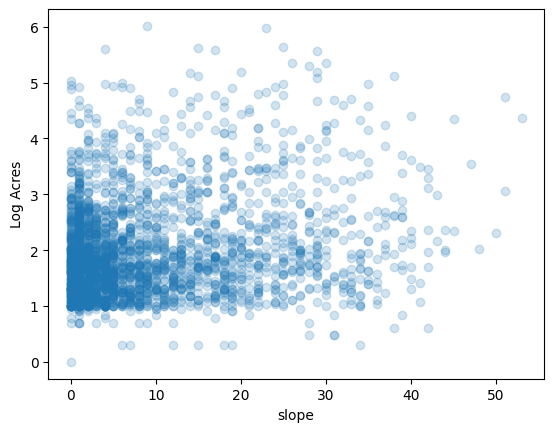

In [84]:
plt.scatter(df['slope'], df['log_acres'], alpha=0.2)
plt.xlabel('slope')
plt.ylabel('Log Acres')
plt.show()

In [87]:
df['slope_bin'] = pd.qcut(
    df['slope'],
    q=10,
    labels=False,
    duplicates='drop'
)

df.groupby('slope_bin')['log_acres'].agg(['mean','count'])

,mean,count
slope_bin,,
0.0,1.877023,612
1.0,1.848902,239
2.0,1.833829,331
3.0,1.943738,132
4.0,1.979356,270
5.0,1.977331,239
6.0,2.164110,267
7.0,2.281442,218
8.0,2.332953,256


In [91]:
print(df['slope'].corr(df['log_acres']))
print(df['log_slope'].corr(df['log_acres']))
print(df['slope_sq'].corr(df['log_acres']))

0.19322729097198263
0.17345460182730588
0.1791802602951165


In [41]:
corr1 = df['elevation'].corr(df['log_acres'])
corr2 = df['log_elevation'].corr(df['log_acres'])


print(corr1)
print(corr2)

0.23338952180088862
0.20554657674017285


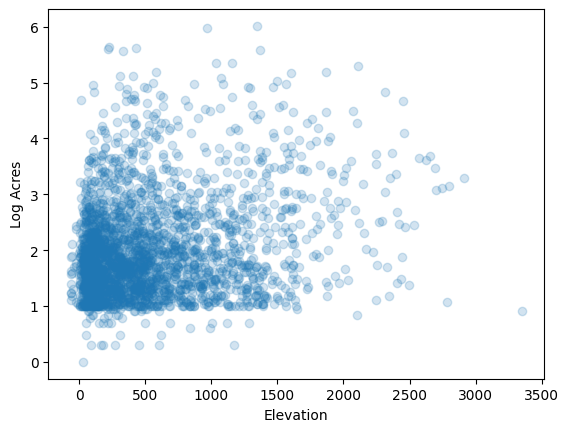

In [39]:
plt.scatter(df['elevation'], df['log_acres'], alpha=0.2)
plt.xlabel('Elevation')
plt.ylabel('Log Acres')
plt.show()

In [69]:
df['elev_bin'] = pd.qcut(df['elevation'], 10)

df.groupby('elev_bin')['log_acres'].mean()

/var/folders/md/v0tk9btn59n4xbtcz2hgwrc80000gn/T/ipykernel_8535/3361425751.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('elev_bin')['log_acres'].mean()


elev_bin
(-64.952, 65.693]       1.723956
(65.693, 116.129]       1.813322
(116.129, 179.365]      1.820307
(179.365, 273.603]      1.931509
(273.603, 379.376]      1.998195
(379.376, 487.357]      2.011013
(487.357, 646.995]      2.073450
(646.995, 898.877]      2.030979
(898.877, 1280.429]     2.085557
(1280.429, 3348.445]    2.532614
Name: log_acres, dtype: float64

In [44]:
df.groupby('elev_bin')['log_acres'].agg(['mean','count'])

/var/folders/md/v0tk9btn59n4xbtcz2hgwrc80000gn/T/ipykernel_8535/646621511.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('elev_bin')['log_acres'].agg(['mean','count'])


,mean,count
elev_bin,,
"(-64.952, 65.693]",1.723956,257
"(65.693, 116.129]",1.813322,256
"(116.129, 179.365]",1.820307,256
"(179.365, 273.603]",1.931509,257
"(273.603, 379.376]",1.998195,256
"(379.376, 487.357]",2.011013,256
"(487.357, 646.995]",2.073450,257
"(646.995, 898.877]",2.030979,256
"(898.877, 1280.429]",2.085557,256
